In [ ]:
# Day 2: Regularized Regression & Residual Diagnostics

# Problem
# Standard Ordinary Least Squares (OLS) regression fails when features are highly correlated (multicollinearity), causing the model to assign wildly unstable weights.
# Furthermore, real-world data contains noise, requiring mathematical constraints to prevent the model from overfitting to the training set.

# So here we will see how 
# 1. Diagnose multicollinearity using the Variance Inflation Factor (VIF).
# 2. Apply Ridge ($L_2$) and Lasso ($L_1$) regularization penalties to control feature weights.
# 3. Analyze residual error distributions to validate the model's predictive assumptions.

In [1]:
# Ingestion & Multicollinearity Check
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Ingest & Split (Reusing California Housing)
data = fetch_california_housing(as_frame=True)
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.2, random_state=42)

# 2. Scale data (VIF and Regularization require identically scaled features)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# 3. Calculate Variance Inflation Factor (VIF)
# VIF > 5 indicates high multicollinearity 
vif_data = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "VIF_Score": [variance_inflation_factor(X_train_scaled.values, i) for i in range(X_train_scaled.shape[1])]
})

display(vif_data.sort_values(by="VIF_Score", ascending=False).round(2))

,Feature,VIF_Score
6,Latitude,9.21
7,Longitude,8.88
2,AveRooms,7.92
3,AveBedrms,6.61
0,MedInc,2.54
1,HouseAge,1.24
4,Population,1.13
5,AveOccup,1.01


In [2]:
# Regularization Penalties
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import root_mean_squared_error, r2_score

# 1. Initialize benchmark models with different penalty functions
models = {
    "OLS (No Penalty)": LinearRegression(),
    "Ridge (L2 Penalty)": Ridge(alpha=10.0),
    "Lasso (L1 Penalty)": Lasso(alpha=0.01),
    "ElasticNet (L1 + L2)": ElasticNet(alpha=0.01, l1_ratio=0.5)
}

# 2. Train and evaluate
results = []
coefficients = pd.DataFrame(index=X_train_scaled.columns)

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    
    results.append({
        "Model": name, 
        "RMSE": root_mean_squared_error(y_test, preds), 
        "R2_Score": r2_score(y_test, preds)
    })
    coefficients[name] = model.coef_

display(pd.DataFrame(results).set_index("Model").round(4))

,RMSE,R2_Score
Model,,
OLS (No Penalty),0.7456,0.5758
Ridge (L2 Penalty),0.7453,0.5761
Lasso (L1 Penalty),0.7404,0.5816
ElasticNet (L1 + L2),0.7416,0.5803


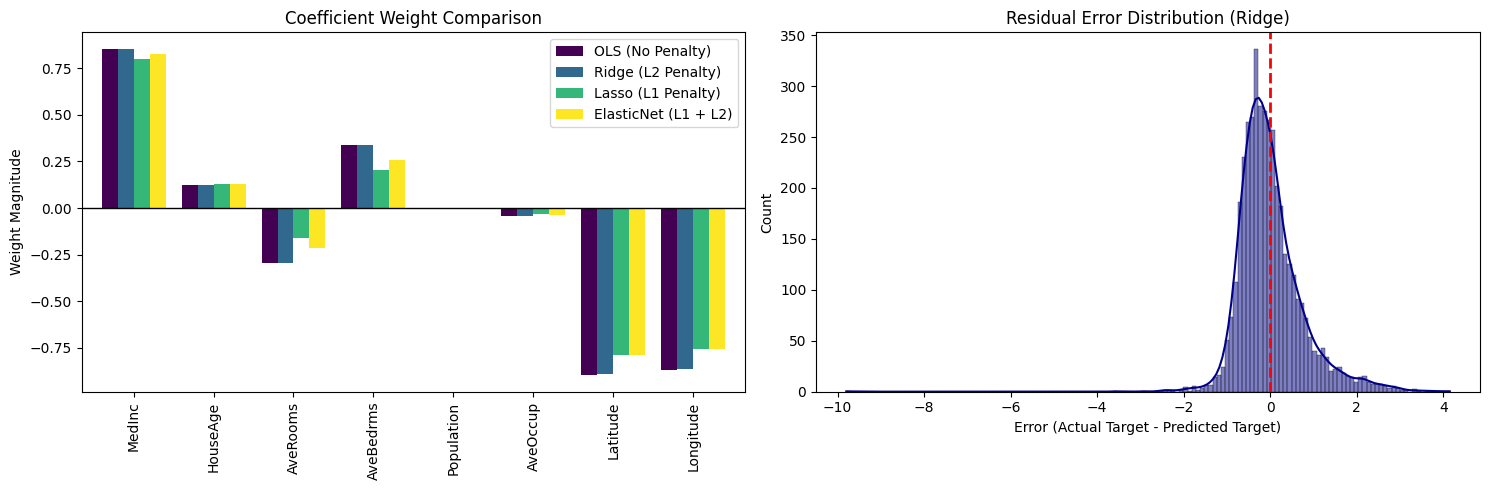

In [3]:
# Visualizing Sparsity & Residuals
# Create a dual-plot figure
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Coefficient Shrinkage (How penalties affect feature weights)
coefficients.plot(kind='bar', ax=axes[0], colormap='viridis', width=0.8)
axes[0].set_title("Coefficient Weight Comparison")
axes[0].set_ylabel("Weight Magnitude")
axes[0].axhline(0, color='black', linewidth=1)
axes[0].legend(loc='upper right')

# Plot 2: Residual Error Distribution (Using Ridge)
ridge_preds = models["Ridge (L2 Penalty)"].predict(X_test_scaled)
residuals = y_test - ridge_preds
sns.histplot(residuals, kde=True, ax=axes[1], color='darkblue')
axes[1].set_title("Residual Error Distribution (Ridge)")
axes[1].set_xlabel("Error (Actual Target - Predicted Target)")
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)

plt.tight_layout()
plt.show()

In [ ]:
# Cell-by-Cell Logic Breakdown
# Cell 2 (VIF Check):
# >The Variance Inflation Factor measures how much a feature's variance is artificially inflated due to collinearity with other features.
# >We use `StandardScaler` first because regularization and VIF mathematically require all features to have a mean of 0 and a standard deviation of 1.

# Cell 3 (Regularization Benchmark):
# >We loop through four regression algorithms. OLS applies no penalty.
# >Ridge ($L_2$) penalizes the square of the weights, forcing them to shrink and preventing any single feature from dominating.
# >Lasso ($L_1$) penalizes the absolute value of the weights, which acts as a mathematical feature selector by forcing useless weights to exactly zero. ElasticNet blends both.

# Cell 4 (Visual Diagnostics):
# The coefficient bar chart exposes the "black box" of the regression equations, showing exactly how $L_1$ and $L_2$ penalties alter the network's mathematical priorities.
# The residual histogram checks the assumption of homoscedasticity; if the curve was skewed left or right, it would indicate the model is fundamentally biased.

# key features we used here
# 1. Multicollinearity Diagnostics: The VIF test revealed severe correlation between `Latitude` and `Longitude`.
# OLS handles this poorly, leading to erratic coefficient assignments.
# 2. L1 vs L2 Mechanics: The coefficient plot visualizes how Lasso ($L_1$) acts as an automatic feature selector by driving less critical weights to absolute zero (sparsity).
# Ridge ($L_2$) shrinks extreme weights proportionally but retains all features. 
# 3. Residual Homoscedasticity: The residual histogram is normally distributed and centered at zero.
# This proves the model is not systematically overestimating or underestimating the target, validating the linear assumption.